In [3]:
import pandas as pd
import numpy as np

df = pd.read_csv('/content/drive/MyDrive/final_gdp_co2_dataset.csv')
df.head()

,country,year,gdp_per_capita_usd,co2_emissions_per_capita_tons,gdp_per_capita_sq
0,China,1994,611.262012,2.582410,3.736412e+05
1,China,1995,1001.162108,2.968782,1.002326e+06
2,China,1996,1408.422417,3.299886,1.983654e+06
3,China,1997,1910.009994,3.680102,3.648138e+06
4,China,1998,2294.856545,3.870424,5.266367e+06


In [4]:
countries = df['country'].unique()
results = {}

for country in countries:
    sub = df[df['country'] == country]
    x = sub['gdp_per_capita_usd'].values
    y = sub['co2_emissions_per_capita_tons'].values

    coeffs = np.polyfit(x, y, 2)
    c2, c1, c0 = coeffs

    y_pred = np.polyval(coeffs, x)
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r2 = 1 - ss_res / ss_tot

    turning_point = -c1 / (2 * c2) if c2 != 0 else None

    results[country] = {
        'c2 (x^2 coeff)': c2, 'c1 (x coeff)': c1, 'c0 (intercept)': c0,
        'R2': r2, 'turning_point_gdp': turning_point
    }

    print(f"--- {country} ---")
    print(f"Coefficients: c2={c2:.3e}, c1={c1:.4f}, c0={c0:.4f}")
    print(f"R^2 = {r2:.2f}")
    if turning_point and turning_point > 0:
        print(f"Turning point (GDP per capita) = ${turning_point:,.0f}")
    else:
        print("Turning point negative/none — still rising or already declining pattern")
    print()

--- China ---
Coefficients: c2=-2.799e-08, c1=0.0009, c0=2.0933
R^2 = 0.99
Turning point (GDP per capita) = $15,508

--- Germany ---
Coefficients: c2=5.578e-10, c1=-0.0001, c0=14.5879
R^2 = 0.84
Turning point (GDP per capita) = $114,277

--- India ---
Coefficients: c2=1.930e-08, c1=0.0004, c0=0.7269
R^2 = 0.99
Turning point negative/none — still rising or already declining pattern

--- Japan ---
Coefficients: c2=-1.770e-08, c1=0.0013, c0=-14.5564
R^2 = 0.11
Turning point (GDP per capita) = $36,975

--- Norway ---
Coefficients: c2=2.557e-10, c1=-0.0001, c0=13.9196
R^2 = 0.94
Turning point (GDP per capita) = $177,931



In [5]:
results_df = pd.DataFrame(results).T
results_df

,c2 (x^2 coeff),c1 (x coeff),c0 (intercept),R2,turning_point_gdp
China,-2.798549e-08,0.000868,2.093305,0.987841,15508.066571
Germany,5.578056e-10,-0.000127,14.587880,0.835030,114277.350917
India,1.929777e-08,0.000351,0.726880,0.985843,-9090.190886
Japan,-1.769623e-08,0.001309,-14.556355,0.112322,36975.473315
Norway,2.557029e-10,-0.000091,13.919576,0.941797,177930.875356


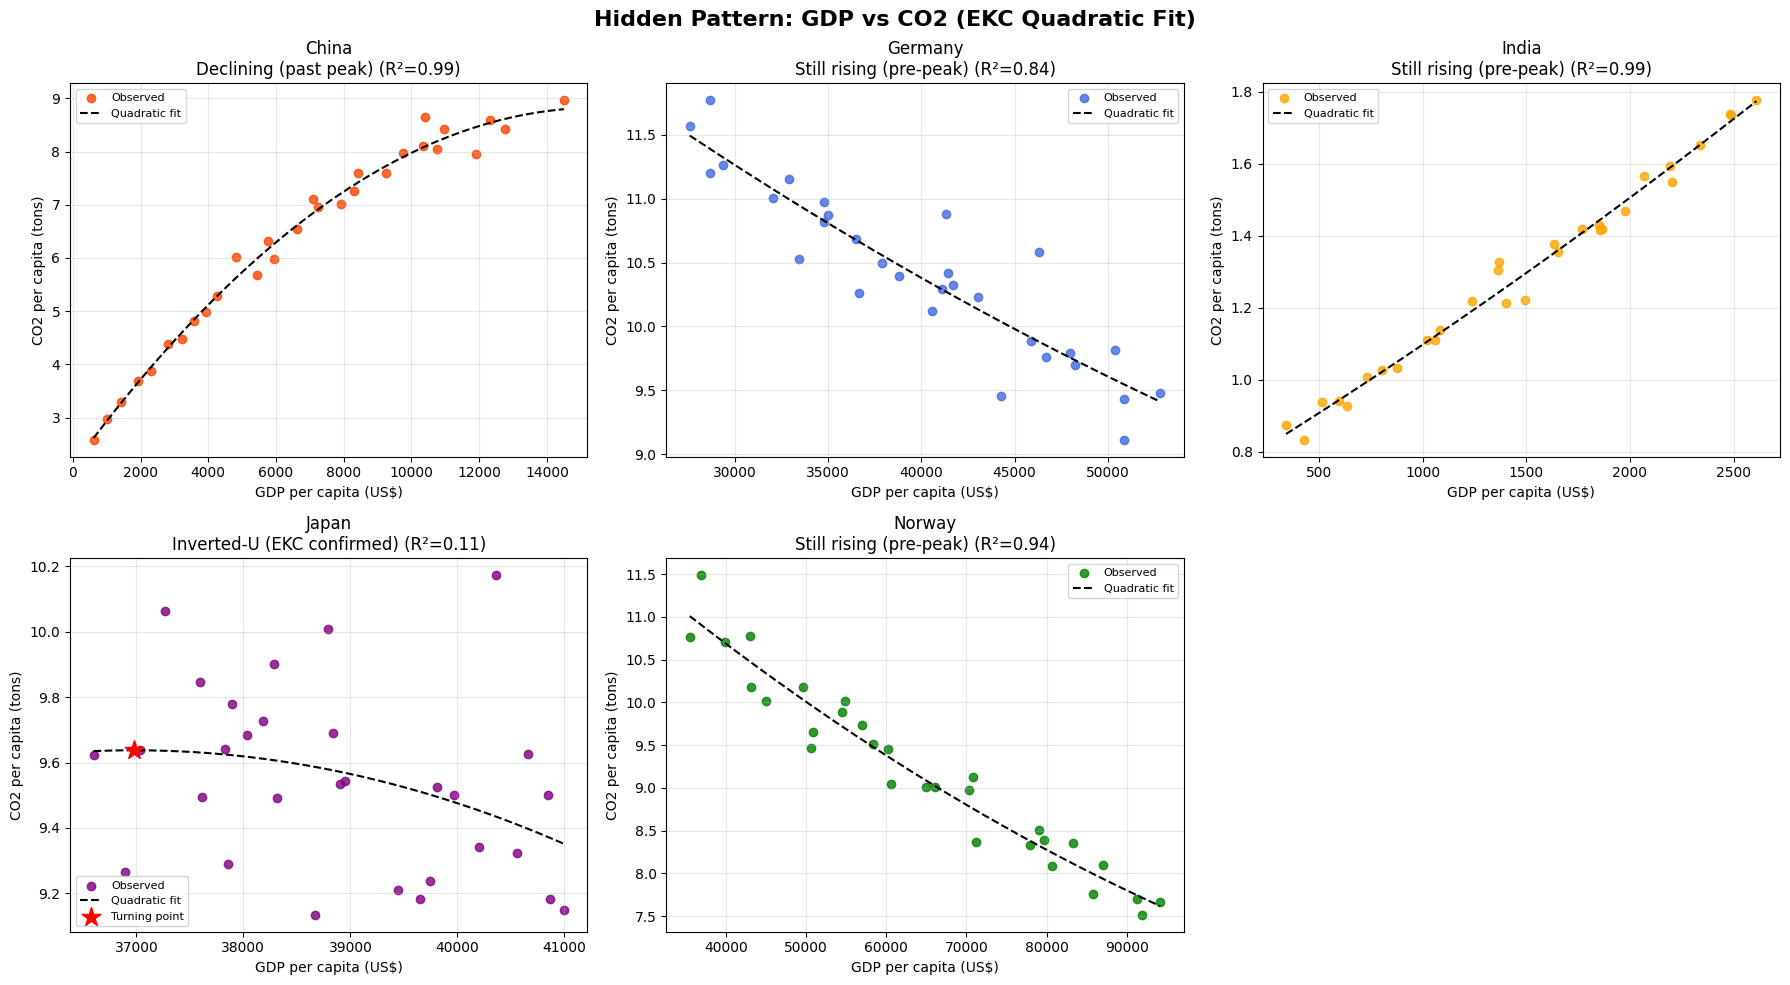

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

colors = ['orangered', 'royalblue', 'orange', 'purple', 'green']

for i, country in enumerate(countries):
    sub = df[df['country'] == country].sort_values('gdp_per_capita_usd')
    x = sub['gdp_per_capita_usd'].values
    y = sub['co2_emissions_per_capita_tons'].values

    coeffs = np.polyfit(x, y, 2)
    c2, c1, c0 = coeffs
    x_line = np.linspace(x.min(), x.max(), 200)
    y_line = np.polyval(coeffs, x_line)

    y_pred = np.polyval(coeffs, x)
    r2 = 1 - np.sum((y - y_pred) ** 2) / np.sum((y - np.mean(y)) ** 2)
    turning_point = -c1 / (2 * c2) if c2 != 0 else None

    ax = axes[i]
    ax.scatter(x, y, color=colors[i], label='Observed', alpha=0.8)
    ax.plot(x_line, y_line, 'k--', label='Quadratic fit')

    if turning_point and x.min() < turning_point < x.max():
        tp_y = np.polyval(coeffs, turning_point)
        ax.scatter([turning_point], [tp_y], color='red', marker='*', s=200,
                   label='Turning point', zorder=5)
        pattern = "Inverted-U (EKC confirmed)"
    elif c2 < 0:
        pattern = "Declining (past peak)"
    else:
        pattern = "Still rising (pre-peak)"

    ax.set_title(f"{country}\n{pattern} (R²={r2:.2f})")
    ax.set_xlabel("GDP per capita (US$)")
    ax.set_ylabel("CO2 per capita (tons)")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

axes[-1].axis('off')
fig.suptitle("Hidden Pattern: GDP vs CO2 (EKC Quadratic Fit)",
              fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('ekc_quadratic_fit.png', dpi=150, bbox_inches='tight')
plt.show()